In [95]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from word2number import w2n
from scipy.stats import zscore

In [254]:
# Create data
data = {
    "Name": ["Alice", "Bob", "charlie", "Bob", None],
    "Age": ["25", "thirty two", "40", "30", "22"],
    "Salary": [50000, 60000, None, 5900000, 45000],
    "JoinDate": ["2021-01-05", "not sure", "2020/12/11", "2022-03-05", ""]
}

df = pd.DataFrame(data)        

In [255]:
# Preview
df.head()

,Name,Age,Salary,JoinDate
0,Alice,25,50000.0,2021-01-05
1,Bob,thirty two,60000.0,not sure
2,charlie,40,NaN,2020/12/11
3,Bob,30,5900000.0,2022-03-05
4,None,22,45000.0,


In [256]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      4 non-null      object 
 1   Age       5 non-null      object 
 2   Salary    4 non-null      float64
 3   JoinDate  5 non-null      object 
dtypes: float64(1), object(3)
memory usage: 292.0+ bytes


In [257]:
df.describe(include="all")

,Name,Age,Salary,JoinDate
count,4,5,4.000000e+00,5
unique,3,5,NaN,5
top,Bob,25,NaN,2021-01-05
freq,2,1,NaN,1
mean,NaN,NaN,1.513750e+06,NaN
std,NaN,NaN,2.924173e+06,NaN
min,NaN,NaN,4.500000e+04,NaN
25%,NaN,NaN,4.875000e+04,NaN
50%,NaN,NaN,5.500000e+04,NaN
75%,NaN,NaN,1.520000e+06,NaN


# Fix Name Casing

In [258]:
# This is a Header 1

In [259]:
# Fix name casing
df["Name"] = df["Name"].str.title()

# Fix Age Values

In [260]:
# Universal method to convert word str to num
# try except clause to catch Value Error incase values are mashed up or have hyphens i.e thirtytwo would throw value error
# while 'thirty two' would result to 32. The except clause will fill any value error to NaN
def safe_word_to_num(x):
    try:
        return w2n.word_to_num(x) if isinstance(x, str) else x
    except ValueError:
        return np.nan

df['Age'] = df['Age'].apply(safe_word_to_num)

In [261]:
df

,Name,Age,Salary,JoinDate
0,Alice,25,50000.0,2021-01-05
1,Bob,32,60000.0,not sure
2,Charlie,40,NaN,2020/12/11
3,Bob,30,5900000.0,2022-03-05
4,None,22,45000.0,


In [262]:
# Replace Nan with Mean value if a value error is caught and replaced with Nan, then replace Nan with mean value
# Convert back to an integer type
df['Age'] = df['Age'].fillna(df['Age'].mean().round().astype('int'))

In [263]:
df

,Name,Age,Salary,JoinDate
0,Alice,25,50000.0,2021-01-05
1,Bob,32,60000.0,not sure
2,Charlie,40,NaN,2020/12/11
3,Bob,30,5900000.0,2022-03-05
4,None,22,45000.0,


# Fix Salary Column

In [264]:
# Fix missing salary value with median
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

# Fix Date Column

In [265]:
df["JoinDate"] = pd.to_datetime(df["JoinDate"], errors="coerce")

In [266]:
df

,Name,Age,Salary,JoinDate
0,Alice,25,50000.0,2021-01-05
1,Bob,32,60000.0,NaT
2,Charlie,40,55000.0,NaT
3,Bob,30,5900000.0,2022-03-05
4,None,22,45000.0,NaT


# Check for outlier using z-score

In [267]:
df["Salary_z"] = zscore(df["Salary"]).round(2)

In [268]:
# Max zscore value is 2, rest of data lies between 0 and 0.5
# Using zscore 2 as a conservative approach since data is small. Universally recommended would be +-2.5 or +-3
df[df["Salary_z"].abs() >= 2]

,Name,Age,Salary,JoinDate,Salary_z
3,Bob,30,5900000.0,2022-03-05,2.0


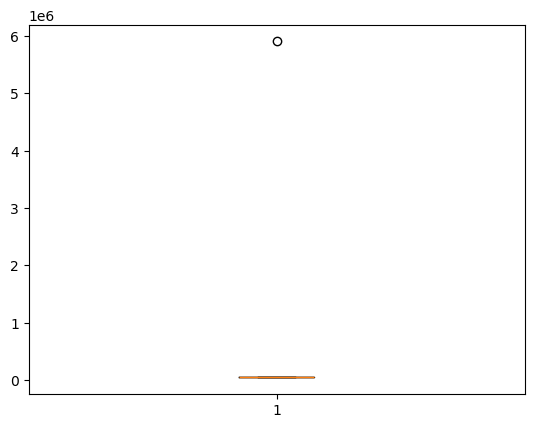

In [269]:
plt.boxplot(df["Salary"])
plt.show()

# Remove Outlier

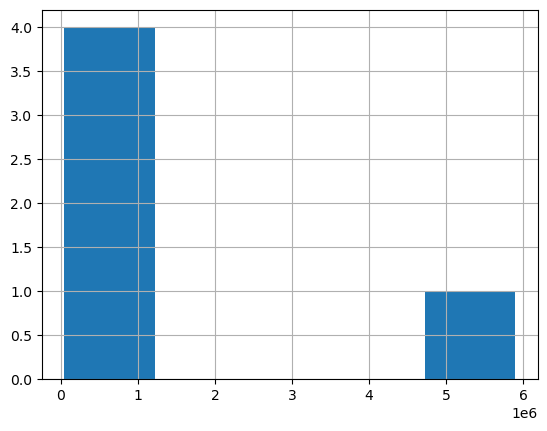

In [270]:
# Evidence shows outlier value
df["Salary"].hist(bins=5)
plt.show()

# Remove Outliers

In [271]:
df_new = df[df["Salary_z"].abs() < 2].drop(columns="Salary_z")

In [272]:
df_new

,Name,Age,Salary,JoinDate
0,Alice,25,50000.0,2021-01-05
1,Bob,32,60000.0,NaT
2,Charlie,40,55000.0,NaT
4,None,22,45000.0,NaT


# Check Duplicates

In [273]:
df_new.duplicated().sum()

np.int64(0)

In [274]:
df_new = df_new.drop_duplicates()

In [275]:
df_new

,Name,Age,Salary,JoinDate
0,Alice,25,50000.0,2021-01-05
1,Bob,32,60000.0,NaT
2,Charlie,40,55000.0,NaT
4,None,22,45000.0,NaT


# Replace None values in Name column with Unknown

In [276]:
df_new['Name'] = df_new['Name'].apply(lambda x: 'Unknown' if x is None else x)

In [277]:
df_new

,Name,Age,Salary,JoinDate
0,Alice,25,50000.0,2021-01-05
1,Bob,32,60000.0,NaT
2,Charlie,40,55000.0,NaT
4,Unknown,22,45000.0,NaT


# Convert NaT rows into a sequence of placeholder dates

In [283]:
df_new['JoinDate'] = pd.to_datetime(df_new['JoinDate'])

In [285]:
# find the first valid date
start_date = df_new['JoinDate'].min()

In [289]:
pd.date_range(start=start_date, periods=len(df_new), freq='D')

DatetimeIndex(['2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08'], dtype='datetime64[ns]', freq='D')

In [290]:
# create sequential dates for all rows
df_new['JoinDate'] = pd.date_range(start=start_date, periods=len(df_new), freq='D')

In [291]:
df_new

,Name,Age,Salary,JoinDate
0,Alice,25,50000.0,2021-01-05
1,Bob,32,60000.0,2021-01-06
2,Charlie,40,55000.0,2021-01-07
4,Unknown,22,45000.0,2021-01-08
